Feature Selection⏬

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# Define the file path
file_path="/content/drive/My Drive/cars.csv"
# Load the dataset
data = pd.read_csv(file_path)

# Display the first few rows of the dataset to understand its structure
data.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Sales in Thousands,Year Resale Value,Price in Thousands,Engine Size,Horsepower,Wheelbase,Width,Length,Curb Weight,Fuel Capacity,Fuel Efficiency,Power Perf Factor,Vehicle Type Car,Vehicle Type Passenger
0,16.919,16.360,21.500,1.8,140,101.2,67.3,172.4,2.639,13.2,28,58.280150,0,1
1,39.384,19.875,28.400,3.2,225,108.1,70.3,192.9,3.517,17.2,25,91.370778,0,1
2,20.397,22.255,23.990,1.8,150,102.6,68.2,178.0,2.998,16.4,27,62.777639,0,1
3,18.780,23.555,33.950,2.8,200,108.7,76.1,192.0,3.561,18.5,22,84.565105,0,1
4,91.561,12.475,21.975,3.1,175,109.0,72.7,194.6,3.368,17.5,25,71.181451,0,1


Price in Thousands        1.000000
Power Perf Factor         0.898002
Year Resale Value         0.871044
Horsepower                0.862995
Curb Weight               0.755530
Engine Size               0.694691
Fuel Capacity             0.498726
Length                    0.482884
Width                     0.453516
Wheelbase                 0.336691
Vehicle Type Car          0.167606
Sales in Thousands       -0.095236
Vehicle Type Passenger   -0.167606
Fuel Efficiency          -0.584143
Name: Price in Thousands, dtype: float64


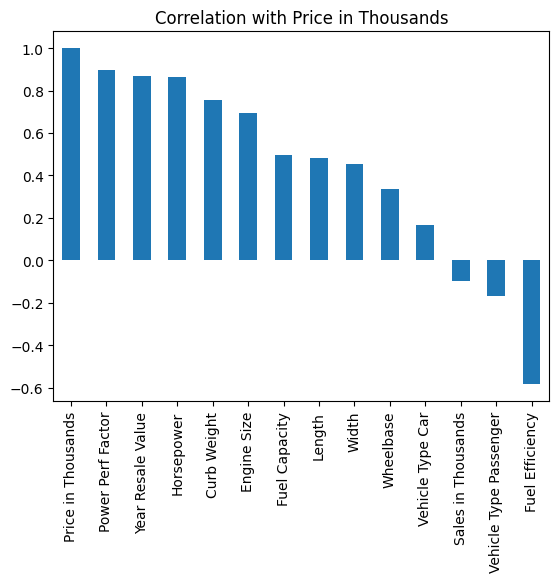

In [ ]:
# Check for correlation between features and the target variable
correlations = data.corr()['Price in Thousands'].sort_values(ascending=False)
print(correlations)

# Plotting correlations to visually analyze them
correlations.plot(kind='bar')
plt.title('Correlation with Price in Thousands')
plt.show()


Model implementation⏬

In [ ]:
feature="Power Perf Factor"

x=data[feature].values
y=data['Price in Thousands'].values

n=len(x)

sum_x=np.sum(x)
sum_y=np.sum(y)
sum_xy=np.sum(x*y)
sum_x2=np.sum(x**2)

m=(n*sum_xy-sum_x*sum_y)/(n*sum_x2-sum_x**2)
b=(sum_y* sum_x2-sum_x*sum_xy)/(n*sum_x2-sum_x**2)

print("Slope (m):", m)
print("Intercept (b):", b)

Slope (m): 0.34557358985506276
Intercept (b): -2.1568740851184303


Prediction and Evaluation⏬

In [ ]:
def predict(x,m,b):
  return m*x+b

y_pred=predict(x,m,b)

RSS=np.sum((y-y_pred)**2)

MSE=RSS/n

RMSE=np.sqrt(MSE)

R2=1-(RSS/np.sum((y-np.mean(y))**2))

print("RSS:",RSS)
print("MSE:",MSE)
print("RMSE:",RMSE)
print("R2:",R2)

RSS: 874.8862415031097
MSE: 8.748862415031097
RMSE: 2.957847598344292
R2: 0.8064070039201181


Model Validation⏬

In [ ]:
for feature in data.columns:
  if feature!="Price in Thousands":
    x=data[feature].values
    n=len(x)

    sum_x=np.sum(x)
    sum_y=np.sum(y)
    sum_xy=np.sum(x*y)
    sum_x2=np.sum(x**2)

    m=(n*sum_xy-sum_x*sum_y)/(n*sum_x2-sum_x**2)
    b=(sum_y* sum_x2-sum_x*sum_xy)/(n*sum_x2-sum_x**2)

    y_pred=predict(x,m,b)

    RSS=np.sum((y-y_pred)**2)
    MSE=RSS/n
    RMSE=np.sqrt(MSE)
    R2=1-(RSS/np.sum((y-np.mean(y))**2))

    print(f'Feature: {feature},   RSS:{RSS},  MSE:{MSE},   RMSE: {RMSE},    R2 Score: {R2}')


Feature: Sales in Thousands,   RSS:4478.214988857139,  MSE:44.782149888571396,   RMSE: 6.691946644181452,    R2 Score: 0.00906996172072383
Feature: Year Resale Value,   RSS:1090.4020088590505,  MSE:10.904020088590505,   RMSE: 3.302123572580303,    R2 Score: 0.7587181260687419
Feature: Engine Size,   RSS:2338.25676970668,  MSE:23.3825676970668,   RMSE: 4.835552470717984,    R2 Score: 0.4825954367805958
Feature: Horsepower,   RSS:1153.4810366636973,  MSE:11.534810366636973,   RMSE: 3.3962936219704227,    R2 Score: 0.7447601308423828
Feature: Wheelbase,   RSS:4006.90236265253,  MSE:40.0690236265253,   RMSE: 6.330009765120849,    R2 Score: 0.11336103302671086
Feature: Width,   RSS:3589.710505073293,  MSE:35.89710505073293,   RMSE: 5.991419285172165,    R2 Score: 0.20567637394478921
Feature: Length,   RSS:3465.429608063369,  MSE:34.65429608063369,   RMSE: 5.886789964032494,    R2 Score: 0.23317699067218223
Feature: Curb Weight,   RSS:1939.5258067289813,  MSE:19.395258067289813,   RMSE: 4.40

cost function

In [ ]:
def cost_function(x, y, W):
    m = len(y)
    y_pred = np.dot(x, W)
    cost = (1 / (2 * m)) * np.sum((y_pred - y) ** 2)
    return cost


gradient descent algorithm

In [ ]:
def gradient_descent(x, y, W, alpha, num_iterations):
  m=len(y)
  cost_history=np.zeros(iteration)
  for i in range(num_iterations):
    y_pred=np.dot(x,W)
    error=y_pred-y
    gradient=np.dot(x.T,error)/m
    W=W-alpha*gradient
    cost_history[i]=cost_function(x,y,W)
  return W,cost_history


Model Training

In [ ]:
data.head()

,Sales in Thousands,Year Resale Value,Price in Thousands,Engine Size,Horsepower,Wheelbase,Width,Length,Curb Weight,Fuel Capacity,Fuel Efficiency,Power Perf Factor,Vehicle Type Car,Vehicle Type Passenger
0,16.919,16.360,21.500,1.8,140,101.2,67.3,172.4,2.639,13.2,28,58.280150,0,1
1,39.384,19.875,28.400,3.2,225,108.1,70.3,192.9,3.517,17.2,25,91.370778,0,1
2,20.397,22.255,23.990,1.8,150,102.6,68.2,178.0,2.998,16.4,27,62.777639,0,1
3,18.780,23.555,33.950,2.8,200,108.7,76.1,192.0,3.561,18.5,22,84.565105,0,1
4,91.561,12.475,21.975,3.1,175,109.0,72.7,194.6,3.368,17.5,25,71.181451,0,1


In [ ]:
features=['Year Resale Value','Width','Length','Fuel Capacity','Wheelbase','Curb Weight','Power Perf Factor']
x=data[features].values
y=data[['Price in Thousands','Horsepower']].values

x=np.c_[np.ones(x.shape[0]),x]

w=np.zeros((x.shape[1],y.shape[1]))

alpha=0.01
iteration=1000

w, cost_history=gradient_descent(x, y,w,alpha, iteration)


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
<ipython-input-22-87763f0810d1>:4: RuntimeWarning: overflow encountered in square
  cost = (1 / (2 * m)) * np.sum((y_pred - y) ** 2)
<ipython-input-23-1532939d2927>:8: RuntimeWarning: invalid value encountered in subtract
  W=W-alpha*gradient


Model Validation

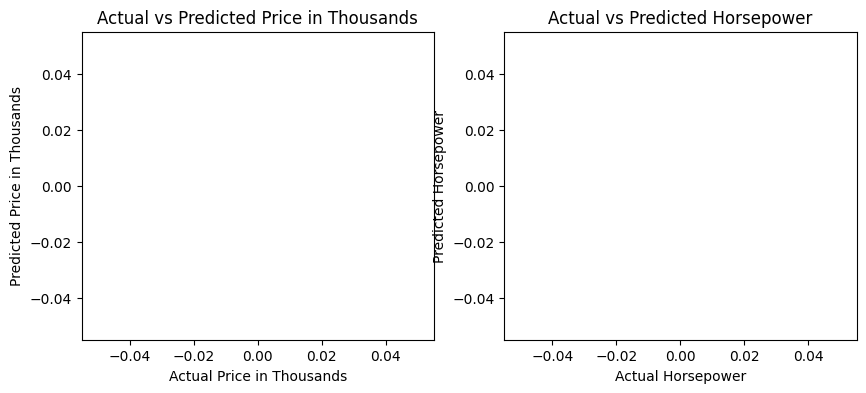

In [ ]:
predictions=x.dot(w)

plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
plt.scatter(y[:, 0], predictions[:, 0], c='blue')
plt.xlabel('Actual Price in Thousands')
plt.ylabel('Predicted Price in Thousands')
plt.title('Actual vs Predicted Price in Thousands')


plt.subplot(1, 2, 2)
plt.scatter(y[:, 1], predictions[:, 1], c='red')
plt.xlabel('Actual Horsepower')
plt.ylabel('Predicted Horsepower')
plt.title('Actual vs Predicted Horsepower')

plt.show()


Learning Curve

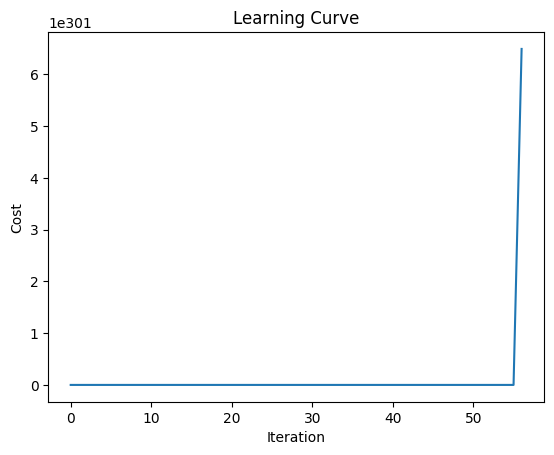

In [ ]:
plt.plot(range(iteration), cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Learning Curve')
plt.show()


 Implementation of Manual K-Fold Cross-Validation from Scratc

K-Fold Data Splitting:

In [46]:

def k_fold_split(X, y, K):
    fold_size = len(X) // K
    indices = np.arange(len(X))
    np.random.shuffle(indices)

    fold = []
    for k in range(K):
        start = k * fold_size
        end = start + fold_size
        fold_indices = indices[start:end]
        fold.append((X[fold_indices], y[fold_indices]))

    return folds


raining with Gradient Descent

In [53]:
def train_k_fold(x,y,k,alpha,iteration):
  performance_metrics=[]
  folds=k_fold_split(x,y,k)
  for i in range(k):
    x_val,y_val = fold[i]

    x_train=np.vstack([folds[j][0] for j in range(k) if j!=i])
    y_train=np.vstack([folds[j][1] for j in range(k) if j!=i])

    W, cost_history = gradient_descent(X_train, y_train, W, alpha, iterations)
    predictions = X_val.dot(W)
    mse = np.mean((predictions - y_val) ** 2)


    performance_metrics.append(mse)

    return performance_metrics



Average Performance Metrics

In [55]:
performance_metrics= train_k_fold(x,y,k=5,alpha=0.01,iteration=1000)
mean_performance= np.mean(performance_metrics)

print(mean_performance)

NameError: name 'folds' is not defined

⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰

Use Built-in Functions

In [56]:
data.head()

,Sales in Thousands,Year Resale Value,Price in Thousands,Engine Size,Horsepower,Wheelbase,Width,Length,Curb Weight,Fuel Capacity,Fuel Efficiency,Power Perf Factor,Vehicle Type Car,Vehicle Type Passenger
0,16.919,16.360,21.500,1.8,140,101.2,67.3,172.4,2.639,13.2,28,58.280150,0,1
1,39.384,19.875,28.400,3.2,225,108.1,70.3,192.9,3.517,17.2,25,91.370778,0,1
2,20.397,22.255,23.990,1.8,150,102.6,68.2,178.0,2.998,16.4,27,62.777639,0,1
3,18.780,23.555,33.950,2.8,200,108.7,76.1,192.0,3.561,18.5,22,84.565105,0,1
4,91.561,12.475,21.975,3.1,175,109.0,72.7,194.6,3.368,17.5,25,71.181451,0,1


In [61]:

from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = data[[ 'Power Perf Factor', 'Year Resale Value','Horsepower']]
y = data[['Price in Thousands']]

model = LinearRegression()

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

mse_scores = []
r2_scores = []

for train_index, val_index in kf.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    mse = mean_squared_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    mse_scores.append(mse)
    r2_scores.append(r2)

mean_mse = np.mean(mse_scores)
mean_r2 = np.mean(r2_scores)

print(f"Mean MSE across all folds (scikit-learn): {mean_mse}")
print(f"Mean R^2 across all folds (scikit-learn): {mean_r2}")


Mean MSE across all folds (scikit-learn): 0.11102563754813081
Mean R^2 across all folds (scikit-learn): 0.9974716368278053


Report Findings

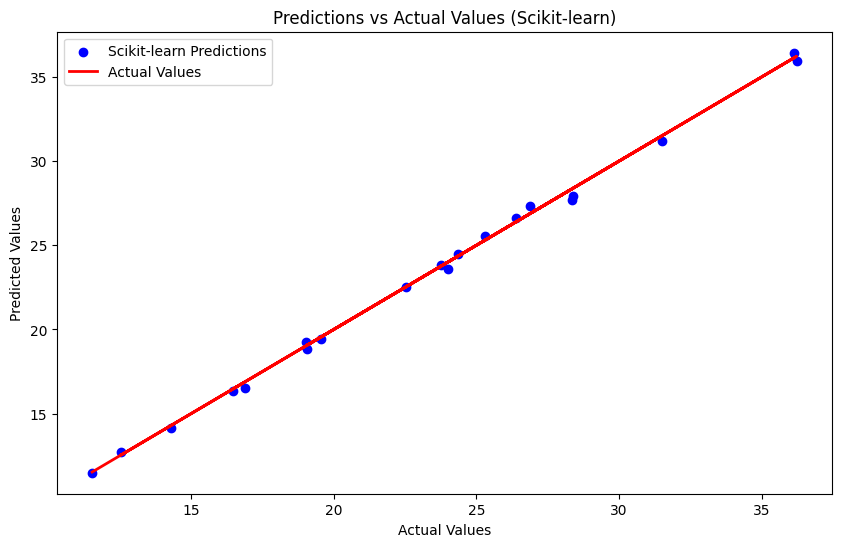

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(y_val, y_pred, color='blue', label='Scikit-learn Predictions')
plt.plot(y_val, y_val, color='red', linewidth=2, label='Actual Values')

plt.title('Predictions vs Actual Values (Scikit-learn)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()
